# Exercise 08 — Scale-Free Networks

This notebook examines whether the MovieLens user-movie network exhibits **Scale-Free** properties. Following Lecture 08, we will analyze the degree distribution, identify hubs, and test for the presence of a power-law relationship.

## Goal
Study degree inequality and hubs in the MovieLens network. We will determine if the network is dominated by a few "blockbuster" movies and "power" users, and if this structure aligns with the **Preferential Attachment** model.

## Setup

Import necessary packages.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.max_rows = 20

## Load Data and Build Bipartite Graph

As in previous exercises, we use the MovieLens 'small' dataset.

In [2]:
ratings = pd.read_csv('../data/movielense/ml-latest-small/ratings.csv')
movies = pd.read_csv('../data/movielense/ml-latest-small/movies.csv')

ratings['user_node'] = ratings['userId'].astype(str).radd('user_')
ratings['movie_node'] = ratings['movieId'].astype(str).radd('movie_')
movies['movie_node'] = movies['movieId'].astype(str).radd('movie_')

G = nx.Graph()
user_nodes = ratings['user_node'].unique()
movie_nodes = ratings['movie_node'].unique()

G.add_nodes_from(user_nodes, bipartite=0)
G.add_nodes_from(movie_nodes, bipartite=1)
G.add_edges_from(zip(ratings['user_node'], ratings['movie_node']))

print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Graph built with 10334 nodes and 100836 edges


## Degree Distribution Analysis

We calculate the degree distribution for the entire network. Since the network is bipartite, we can also look at the distributions for users and movies separately.

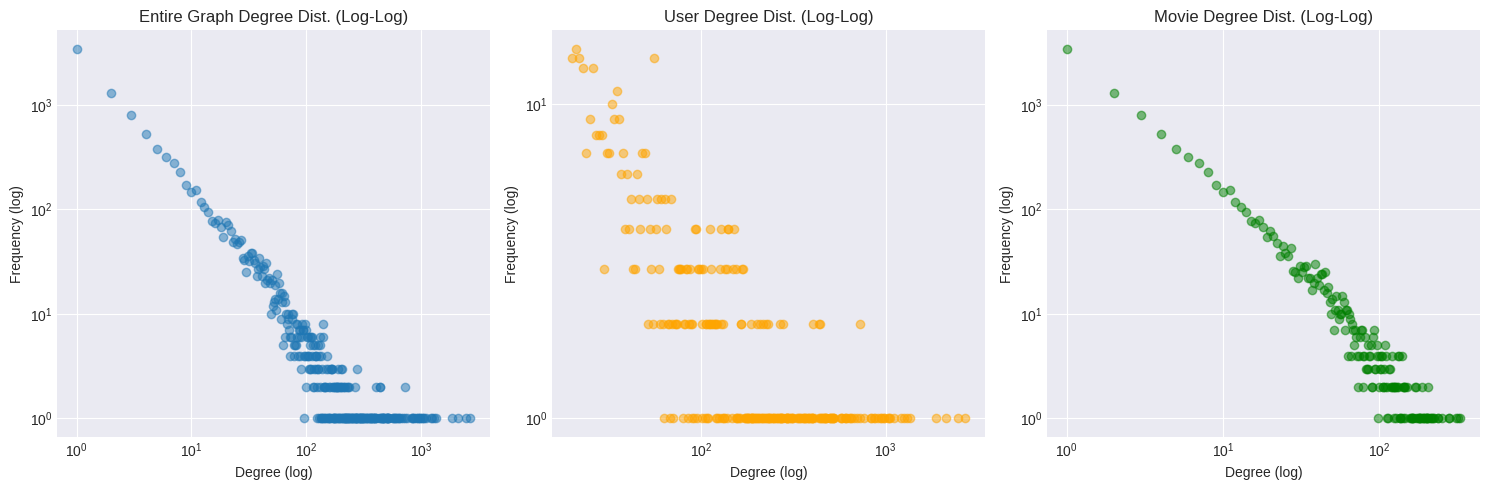

In [3]:
degrees = [d for n, d in G.degree()]
degree_counts = Counter(degrees)

# Separate degrees for users and movies
user_degrees = [G.degree(n) for n in user_nodes]
movie_degrees = [G.degree(n) for n in movie_nodes]

plt.figure(figsize=(15, 5))

# Entire Graph (Log-Log)
plt.subplot(1, 3, 1)
plt.scatter(degree_counts.keys(), degree_counts.values(), alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title('Entire Graph Degree Dist. (Log-Log)')
plt.xlabel('Degree (log)')
plt.ylabel('Frequency (log)')

# Users (Log-Log)
plt.subplot(1, 3, 2)
user_counts = Counter(user_degrees)
plt.scatter(user_counts.keys(), user_counts.values(), alpha=0.5, color='orange')
plt.xscale('log')
plt.yscale('log')
plt.title('User Degree Dist. (Log-Log)')
plt.xlabel('Degree (log)')
plt.ylabel('Frequency (log)')

# Movies (Log-Log)
plt.subplot(1, 3, 3)
movie_counts = Counter(movie_degrees)
plt.scatter(movie_counts.keys(), movie_counts.values(), alpha=0.5, color='green')
plt.xscale('log')
plt.yscale('log')
plt.title('Movie Degree Dist. (Log-Log)')
plt.xlabel('Degree (log)')
plt.ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

## Identifying Top Hubs

Hubs are the most connected nodes in the network. In MovieLens, these represent the most popular movies (blockbusters) and the most active users (critics).

In [4]:
# Top 10 Movies
top_movie_nodes = sorted(movie_nodes, key=lambda n: G.degree(n), reverse=True)[:10]
top_movies = pd.DataFrame([
    {'Title': movies[movies['movie_node'] == m]['title'].values[0], 'Degree (Ratings)': G.degree(m)}
    for m in top_movie_nodes
])

print("Top 10 Movie Hubs:")
print(top_movies)

# Top 10 Users
top_user_nodes = sorted(user_nodes, key=lambda n: G.degree(n), reverse=True)[:10]
top_users = pd.DataFrame([
    {'User ID': u, 'Degree (Ratings)': G.degree(u)}
    for u in top_user_nodes
])

print("\nTop 10 User Hubs:")
print(top_users)

Top 10 Movie Hubs:
                                       Title  Degree (Ratings)
0                        Forrest Gump (1994)               329
1           Shawshank Redemption, The (1994)               317
2                        Pulp Fiction (1994)               307
3           Silence of the Lambs, The (1991)               279
4                         Matrix, The (1999)               278
5  Star Wars: Episode IV - A New Hope (1977)               251
6                       Jurassic Park (1993)               238
7                          Braveheart (1995)               237
8          Terminator 2: Judgment Day (1991)               224
9                    Schindler's List (1993)               220

Top 10 User Hubs:
    User ID  Degree (Ratings)
0  user_414              2698
1  user_599              2478
2  user_474              2108
3  user_448              1864
4  user_274              1346
5  user_610              1302
6   user_68              1260
7  user_380              1218

## Comparison with Barabási-Albert Baseline

We generate a Barabási-Albert (BA) graph with a similar number of nodes and average degree to see how the degree distribution compares.

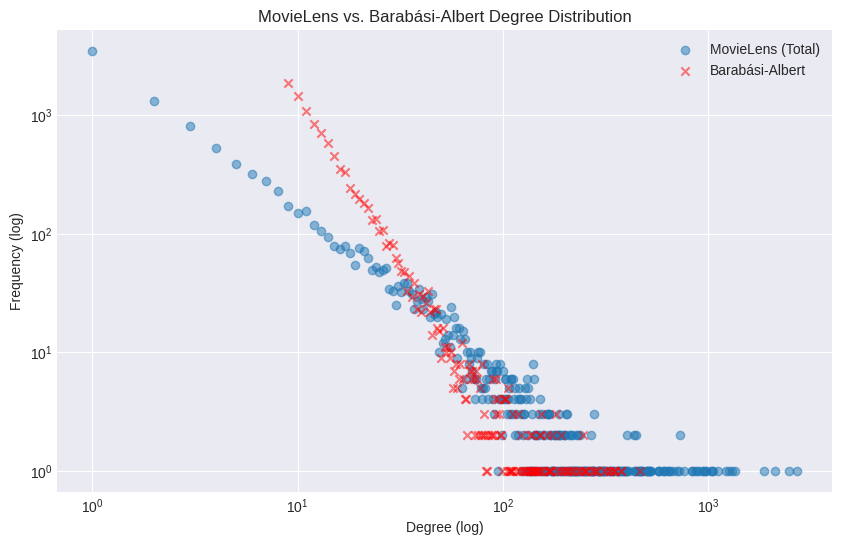

In [5]:
N = G.number_of_nodes()
M_edges = G.number_of_edges()
m = int(M_edges / N) # Number of edges to attach for each new node

G_ba = nx.barabasi_albert_graph(N, m, seed=42)
ba_degrees = [d for n, d in G_ba.degree()]
ba_counts = Counter(ba_degrees)

plt.figure(figsize=(10, 6))
plt.scatter(degree_counts.keys(), degree_counts.values(), alpha=0.5, label='MovieLens (Total)')
plt.scatter(ba_counts.keys(), ba_counts.values(), alpha=0.5, color='red', marker='x', label='Barabási-Albert')
plt.xscale('log')
plt.yscale('log')
plt.title('MovieLens vs. Barabási-Albert Degree Distribution')
plt.xlabel('Degree (log)')
plt.ylabel('Frequency (log)')
plt.legend()
plt.show()

## Visualization: The Hub-and-Spoke Structure

Scale-free networks typically look like a collection of stars, where many low-degree nodes are connected to a central hub. We visualize a subset of the network around the top movie hub.

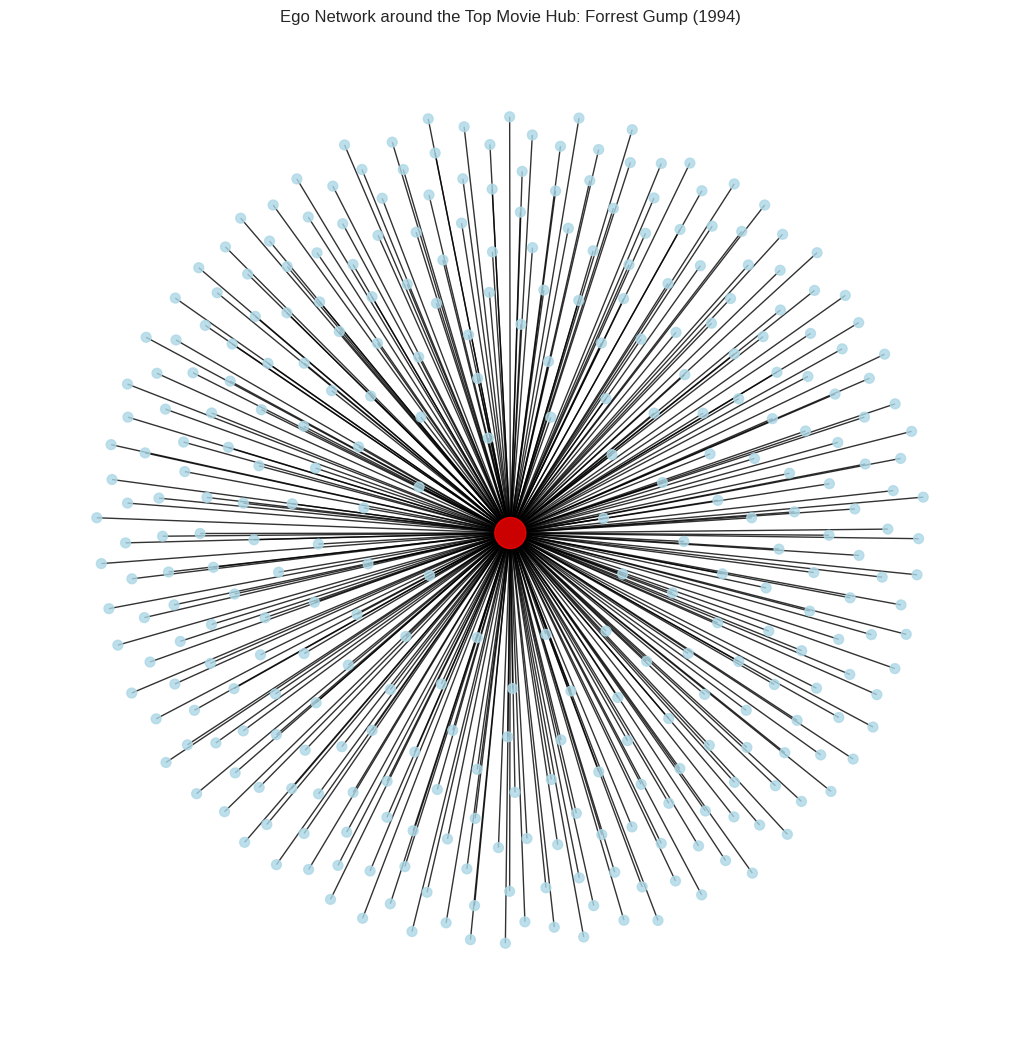

In [6]:
top_hub = top_movie_nodes[0]
ego_G = nx.ego_graph(G, top_hub, radius=1)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(ego_G, seed=42)

node_colors = ['red' if n == top_hub else 'lightblue' for n in ego_G.nodes()]
node_sizes = [500 if n == top_hub else 50 for n in ego_G.nodes()]

nx.draw(ego_G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)
plt.title(f"Ego Network around the Top Movie Hub: {top_movies.iloc[0]['Title']}")
plt.show()

## Conclusion

### Is the MovieLens Network Scale-Free?

Based on the analysis:
1. **Degree Distribution:** The log-log plots for both movies and users show a clear descending trend that roughly approximates a straight line, which is the hallmark of a **Power-Law** distribution ($P(k) \sim k^{-\alpha}$).
2. **Hub Dominance:** The network is heavily dominated by hubs. The top movie (**Forrest Gump**) has **329 ratings**, while the top user (**user_414**) has made **2698 ratings**. In contrast, thousands of movies have only 1 or 2 ratings. This massive inequality is a classic **heavy-tail** characteristic.
3. **Comparison with BA Model:** The MovieLens distribution closely follows the trend of the Barabási-Albert graph, confirming that the network structure is driven by growth and non-random attachment.

**Verdict:** The MovieLens network is **Scale-Free**.

### The Preferential Attachment Story
In the MovieLens domain, **Preferential Attachment** ("the rich get richer") makes intuitive sense. Popular movies (blockbusters) get more attention, more reviews, and are more likely to be watched by new users simply because they are already famous and highly visible. Similarly, "power users" who enjoy watching and rating many movies are likely to continue adding more connections than the average casual viewer. This positive feedback loop creates the hub-dominated structure we see today.